## Evaluation code for the distributions generated by different frameworks
This code includes
- Loading of the feature vectors
- Calculation of logits with different train subset configurations
- Dimensionality reduction with UMAP
- Trustworthiness calculation for outputs with different train subset configurations
- Pairwise trustworthiness calculation for outputs with different train subset configurations
- Stable point selection using pairwise trustworthiness

In [ ]:
import os
### Ensures reproducibility
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"

os.environ["PYTHONWARNINGS"] = "ignore"

In [24]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from joblib import Parallel, delayed
from imblearn.over_sampling import RandomOverSampler
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
import tqdm
import matplotlib.pyplot as plt

import umap
from sklearn.manifold import trustworthiness
from sklearn.neighbors import NearestNeighbors
from itertools import product


In [3]:
### Load labels (histological classifications) and patient ids
labels=np.load('TCGA_full_labels20250624.npy')
patient_id=np.load('TCGA_full_patient_id.npy')
patient_id_unique=np.unique(patient_id)
print("Number of patients:", len(patient_id_unique))
### Train-validation split by patient id
val_patient_id=patient_id_unique[::5]
train_patient_id = np.array([v for i, v in enumerate(patient_id_unique) if i % 5 != 0])
print("Patients in validation dataset:",len(val_patient_id))
print("Patients in train dataset:",len(train_patient_id))

Number of patients: 313
Patients in validation dataset: 63
Patients in train dataset: 250


In [4]:
train_idx=np.where(np.isin(patient_id,train_patient_id))[0]
val_idx=np.where(np.isin(patient_id,val_patient_id))[0]
print("Number of train set patches:",len(train_idx))
print("Number of validation set patches:",len(val_idx))

Number of train set patches: 5240
Number of validation set patches: 1340


In [5]:
### Encode labels
label_encoder = LabelEncoder()
labels_encoded = label_encoder.fit_transform(labels)
for idx, class_label in enumerate(label_encoder.classes_):
    print(f"{idx}: {class_label}")

0: muc
1: pap
2: por1
3: por2
4: sig
5: tub1
6: tub2


### Loading features from different feature extraction methods

In [6]:
### TDA features
pimgs_list=np.load('pimgs_list20260315.npy')
pimgs_list=np.log1p(pimgs_list)
pimgs_reshaped = pimgs_list.reshape(pimgs_list.shape[0], -1)
print("TDA features:",pimgs_reshaped.shape)
### CONCH features
conch_list=np.load('TCGA-gastric-conch20251105.npy')
print("CONCH features:",conch_list.shape)
### UNI features
uni_list=np.load('uni_TCGA_gastric20251224.npy')
print("UNI features:",uni_list.shape)


TDA features: (6580, 1800)
CONCH features: (6580, 768)
UNI features: (6580, 1536)


### Logit calculation for TDA features

In [7]:
# Logit calculation for multiple train subset configurations
### X is feature vector
X = pimgs_reshaped
### Train-validation split
X_train=X[train_idx]
X_val=X[val_idx]
y_train=labels_encoded[train_idx]
y_val=labels_encoded[val_idx]
### Standard scaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)### fit-transform on train dataset
X_val_scaled=scaler.transform(X_val)### transform on validation dataset


### Train subset configurations by setting sampling interval
interval_list=[1,3,6,9,12,15,18,21,24,27,30]
def compute_logits(i):
    X_selected = X_train_scaled[::i]### Train subset
    y_selected = y_train[::i]### Labels for train subset

    ros = RandomOverSampler(random_state=42)
    X_resampled, y_resampled = ros.fit_resample(X_selected, y_selected)

    clf = OneVsRestClassifier(
        LogisticRegression(max_iter=1000)
    )
    clf.fit(X_resampled, y_resampled)

    logits = clf.decision_function(X_val_scaled)### Calculate logits on validation dataset
    return logits


logits_list = Parallel(
    n_jobs=-1,
    backend="loky",
)(
    delayed(compute_logits)(i)
    for i in tqdm.tqdm(interval_list)
)
logits_list=np.array(logits_list)
print("Output logits shape:",logits_list.shape)
print("Accuracy for each train subset configuration:")
pred_classes=np.array([[np.argmax(logits_list[i][j]) for j in range (0,1340)] for i in range (0,11)])
for i in range (0,11):
    print(np.sum(pred_classes[i]==y_val)/1340)

100%|██████████| 11/11 [00:00<00:00, 616.27it/s]


Output logits shape: (11, 1340, 7)
Accuracy for each train subset configuration:
0.5388059701492537
0.5365671641791044
0.5283582089552239
0.5649253731343283
0.5328358208955224
0.5186567164179104
0.5417910447761194
0.5082089552238805
0.5358208955223881
0.5156716417910447
0.48208955223880595


### Logit calculation for UNI features

In [8]:
# Logit calculation for multiple train subset configurations
### X is feature vector
X = uni_list
### Train-validation split
X_train=X[train_idx]
X_val=X[val_idx]
y_train=labels_encoded[train_idx]
y_val=labels_encoded[val_idx]
### Standard scaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)### fit-transform on train dataset
X_val_scaled=scaler.transform(X_val)### transform on validation dataset


### Train subset configurations by setting sampling interval
interval_list=[1,3,6,9,12,15,18,21,24,27,30]
def compute_logits(i):
    X_selected = X_train_scaled[::i]### Train subset
    y_selected = y_train[::i]### Labels for train subset

    ros = RandomOverSampler(random_state=42)
    X_resampled, y_resampled = ros.fit_resample(X_selected, y_selected)

    clf = OneVsRestClassifier(
        LogisticRegression(max_iter=1000)
    )
    clf.fit(X_resampled, y_resampled)

    logits = clf.decision_function(X_val_scaled)### Calculate logits on validation dataset
    return logits


logits_list_uni = Parallel(
    n_jobs=-1,
    backend="loky",
)(
    delayed(compute_logits)(i)
    for i in tqdm.tqdm(interval_list)
)
logits_list_uni=np.array(logits_list_uni)
print("Output logits shape:",logits_list_uni.shape)
print("Accuracy for each train subset configuration:")
pred_classes_uni=np.array([[np.argmax(logits_list_uni[i][j]) for j in range (0,1340)] for i in range (0,11)])
for i in range (0,11):
    print(np.sum(pred_classes_uni[i]==y_val)/1340)

100%|██████████| 11/11 [00:00<00:00, 15741.16it/s]


Output logits shape: (11, 1340, 7)
Accuracy for each train subset configuration:
0.6656716417910448
0.6365671641791045
0.6813432835820895
0.6253731343283582
0.6783582089552239
0.6298507462686567
0.6425373134328358
0.6917910447761194
0.6537313432835821
0.5895522388059702
0.6313432835820896


### Logit calculation for CONCH features

In [9]:
# Logit calculation for multiple train subset configurations
### X is feature vector
X = conch_list
### Train-validation split
X_train=X[train_idx]
X_val=X[val_idx]
y_train=labels_encoded[train_idx]
y_val=labels_encoded[val_idx]
### Standard scaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)### fit-transform on train dataset
X_val_scaled=scaler.transform(X_val)### transform on validation dataset


### Train subset configurations by setting sampling interval
interval_list=[1,3,6,9,12,15,18,21,24,27,30]
def compute_logits(i):
    X_selected = X_train_scaled[::i]### Train subset
    y_selected = y_train[::i]### Labels for train subset

    ros = RandomOverSampler(random_state=42)
    X_resampled, y_resampled = ros.fit_resample(X_selected, y_selected)

    clf = OneVsRestClassifier(
        LogisticRegression(max_iter=1000)
    )
    clf.fit(X_resampled, y_resampled)

    logits = clf.decision_function(X_val_scaled)### Calculate logits on validation dataset
    return logits


logits_list_conch = Parallel(
    n_jobs=-1,
    backend="loky",
)(
    delayed(compute_logits)(i)
    for i in tqdm.tqdm(interval_list)
)
logits_list_conch=np.array(logits_list_conch)
print("Output logits shape:",logits_list_conch.shape)
print("Accuracy for each train subset configuration:")
pred_classes_conch=np.array([[np.argmax(logits_list_conch[i][j]) for j in range (0,1340)] for i in range (0,11)])
for i in range (0,11):
    print(np.sum(pred_classes_conch[i]==y_val)/1340)

100%|██████████| 11/11 [00:00<00:00, 12049.45it/s]


Output logits shape: (11, 1340, 7)
Accuracy for each train subset configuration:
0.7
0.6582089552238806
0.6664179104477612
0.6626865671641791
0.608955223880597
0.6171641791044776
0.6268656716417911
0.6171641791044776
0.5843283582089552
0.5455223880597015
0.5843283582089552


### Adding logits to build combined frameworks

In [10]:
print("T+C")
logits_list_tdaconch=np.array(logits_list_conch)+np.array(logits_list)
pred_classes_tdaconch=np.array([[np.argmax(logits_list_tdaconch[i][j]) for j in range (0,1340)] for i in range (0,11)])
for i in range (0,11):
    print(np.sum(pred_classes_tdaconch[i]==y_val)/1340)
print("U+T")
logits_list_unitda=np.array(logits_list)+np.array(logits_list_uni)
pred_classes_unitda=np.array([[np.argmax(logits_list_unitda[i][j]) for j in range (0,1340)] for i in range (0,11)])
for i in range (0,11):
    print(np.sum(pred_classes_unitda[i]==y_val)/1340)
print("U+C")
logits_list_uniconch=np.array(logits_list_conch)+np.array(logits_list_uni)
pred_classes_uniconch=np.array([[np.argmax(logits_list_uniconch[i][j]) for j in range (0,1340)] for i in range (0,11)])
for i in range (0,11):
    print(np.sum(pred_classes_uniconch[i]==y_val)/1340)
print("full")
logits_list_unitdaconch=np.array(logits_list_uni)+np.array(logits_list)+np.array(logits_list_conch)
pred_classes_unitdaconch=np.array([[np.argmax(logits_list_unitdaconch[i][j]) for j in range (0,1340)] for i in range (0,11)])
for i in range (0,11):
    print(np.sum(pred_classes_unitdaconch[i]==y_val)/1340)


T+C
0.6365671641791045
0.6537313432835821
0.6485074626865671
0.6738805970149254
0.6619402985074627
0.6529850746268657
0.6619402985074627
0.6597014925373135
0.6231343283582089
0.585820895522388
0.6276119402985074
U+T
0.6567164179104478
0.6462686567164179
0.6567164179104478
0.6626865671641791
0.6843283582089552
0.6425373134328358
0.6604477611940298
0.667910447761194
0.6582089552238806
0.6164179104477612
0.6283582089552239
U+C
0.6955223880597015
0.6798507462686567
0.7171641791044776
0.6656716417910448
0.6776119402985075
0.6828358208955224
0.6686567164179105
0.6977611940298507
0.6514925373134328
0.5962686567164179
0.6455223880597015
full
0.6843283582089552
0.6835820895522388
0.6985074626865672
0.685820895522388
0.7029850746268657
0.6940298507462687
0.691044776119403
0.6970149253731344
0.6619402985074627
0.6126865671641791
0.6582089552238806


### Dimensionality reduction with UMAP

In [15]:
warnings.filterwarnings("ignore")
def compute_umap(logits):
    reducer = umap.UMAP(
        random_state=42,
        n_neighbors=15,
        n_jobs=1,
    )
    embedding = reducer.fit_transform(logits)
    return embedding

embedding_tda_list = Parallel(
    n_jobs=-1,            
    backend="loky"
)(
    delayed(compute_umap)(logits)
    for logits in tqdm.tqdm(logits_list)
)
embedding_conch_list = Parallel(
    n_jobs=-1,           
    backend="loky"
)(
    delayed(compute_umap)(logits)
    for logits in tqdm.tqdm(logits_list_conch)
)
embedding_uni_list = Parallel(
    n_jobs=-1,           
    backend="loky"
)(
    delayed(compute_umap)(logits)
    for logits in tqdm.tqdm(logits_list_uni)
)
embedding_tdaconch_list = Parallel(
    n_jobs=-1,           
    backend="loky"
)(
    delayed(compute_umap)(logits)
    for logits in tqdm.tqdm(logits_list_tdaconch)
)
embedding_unitda_list = Parallel(
    n_jobs=-1,            
    backend="loky"
)(
    delayed(compute_umap)(logits)
    for logits in tqdm.tqdm(logits_list_unitda)
)
embedding_uniconch_list = Parallel(
    n_jobs=-1,         
    backend="loky"
)(
    delayed(compute_umap)(logits)
    for logits in tqdm.tqdm(logits_list_uniconch)
)
embedding_uniconchtda_list = Parallel(
    n_jobs=-1,           
    backend="loky"
)(
    delayed(compute_umap)(logits)
    for logits in tqdm.tqdm(logits_list_unitdaconch)
)
embedding_tda_list=np.array(embedding_tda_list)
embedding_uni_list=np.array(embedding_uni_list)
embedding_conch_list=np.array(embedding_conch_list)
embedding_tdaconch_list=np.array(embedding_tdaconch_list)
embedding_unitda_list=np.array(embedding_unitda_list)
embedding_uniconch_list=np.array(embedding_uniconch_list)
embedding_uniconchtda_list=np.array(embedding_uniconchtda_list)

100%|██████████| 11/11 [00:00<00:00, 6419.56it/s]


### Calculate (average) trustworthiness (i.e. usual trustworthiness calculated by averaging all the points)

In [17]:
### Calculation of trustworthiness for all pairs in the embedding list
def trustworthiness_matrix(embedding_list, n_jobs=-1,n_neighbors=5):
    n = len(embedding_list)

    def compute_row_trust(j):
        return [trustworthiness(embedding_list[i], embedding_list[j],n_neighbors=n_neighbors) for i in range(n)]### calculates trustworthiness for one row.

    results = Parallel(n_jobs=n_jobs)(
        delayed(compute_row_trust)(j) for j in tqdm.tqdm(range(n))### calculates trustworthiness for all pairs
    )

    return np.array(results)


Neighborhood size: 5


100%|██████████| 11/11 [00:00<00:00, 5862.43it/s]


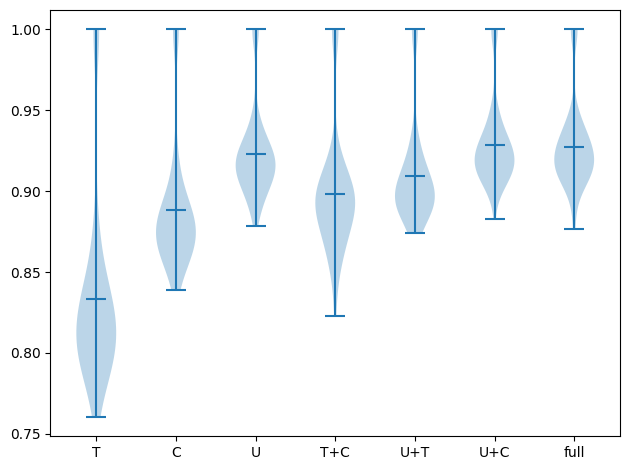

Neighborhood size: 55


100%|██████████| 11/11 [00:00<00:00, 6343.65it/s]


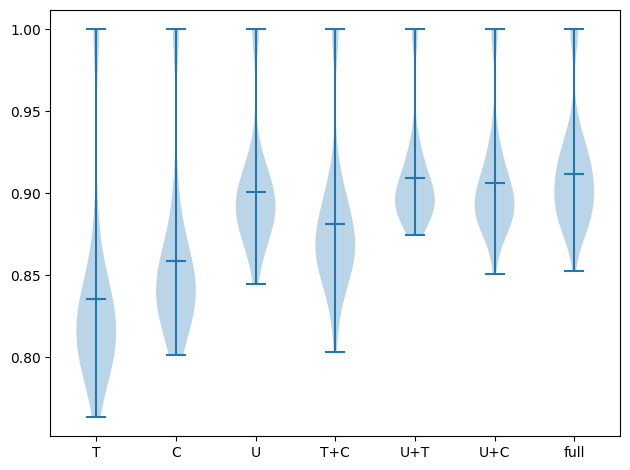

Neighborhood size: 105


100%|██████████| 11/11 [00:00<00:00, 6460.91it/s]


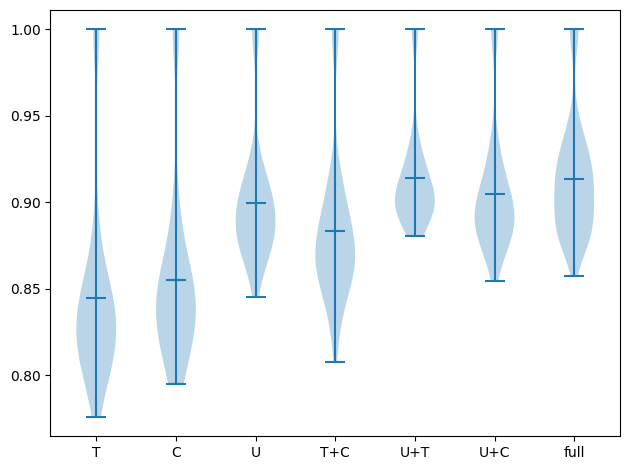

Neighborhood size: 155


100%|██████████| 11/11 [00:00<00:00, 6171.39it/s]


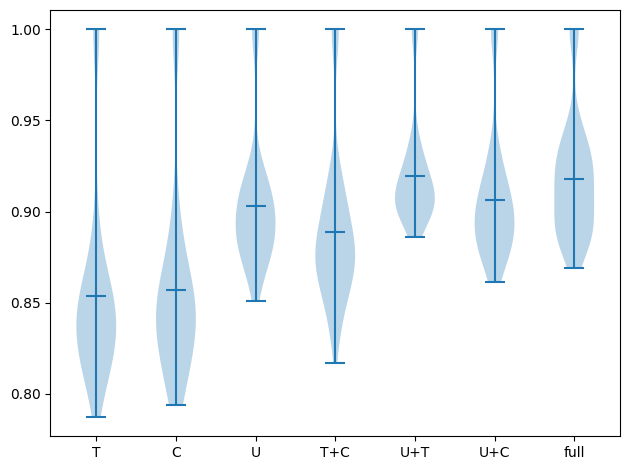

Neighborhood size: 205


100%|██████████| 11/11 [00:00<00:00, 5938.65it/s]


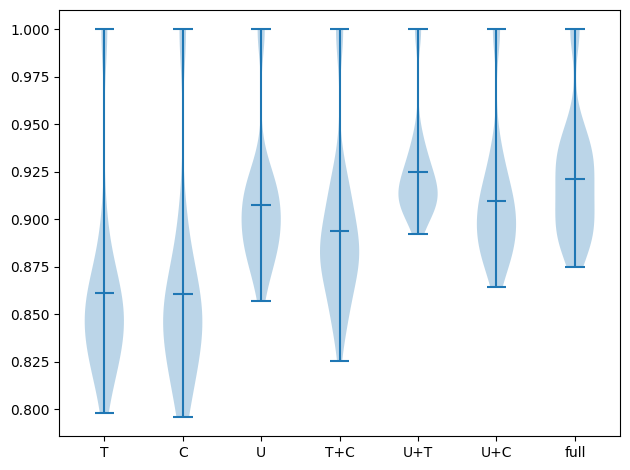

Neighborhood size: 255


100%|██████████| 11/11 [00:00<00:00, 6421.34it/s]


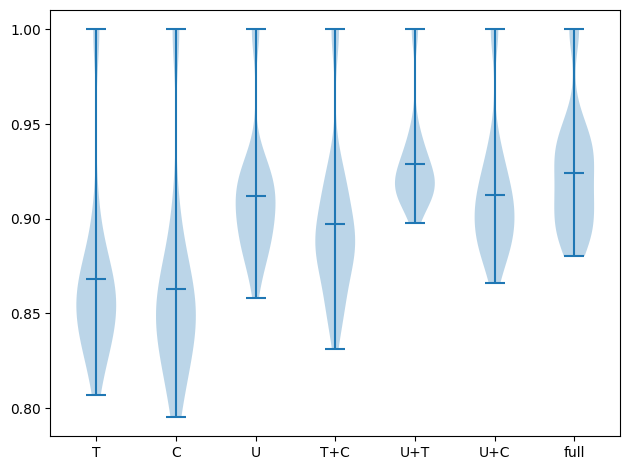

Neighborhood size: 305


100%|██████████| 11/11 [00:00<00:00, 6407.07it/s]


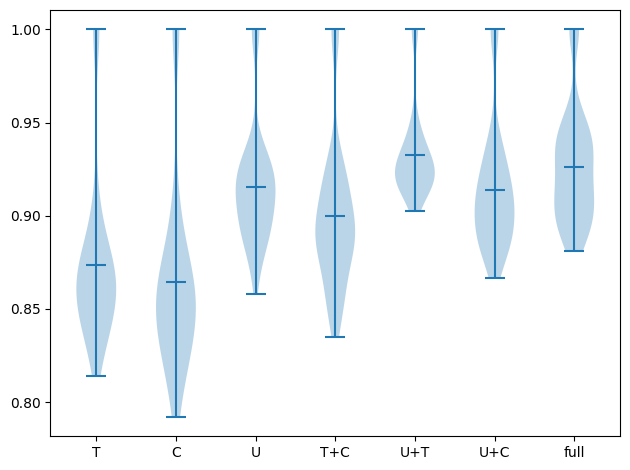

Neighborhood size: 355


100%|██████████| 11/11 [00:00<00:00, 6572.27it/s]


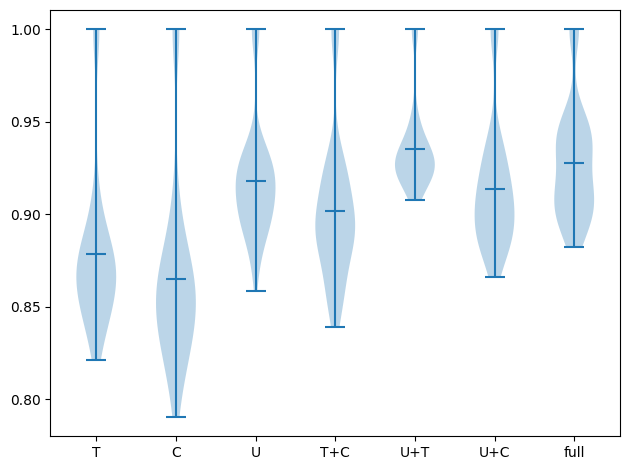

In [18]:
### Violin plot of the results with different neighborhood sizes.
for nbd_num in range (5,400,50):### We try different neighborhood sizes
    print("Neighborhood size:",nbd_num)
    trust_unitda=trustworthiness_matrix(embedding_unitda_list,n_neighbors=nbd_num).flatten()
    trust_uniconch=trustworthiness_matrix(embedding_uniconch_list,n_neighbors=nbd_num).flatten()
    trust_uniconchtda=trustworthiness_matrix(embedding_uniconchtda_list,n_neighbors=nbd_num).flatten()
    trust_tda=trustworthiness_matrix(embedding_tda_list,n_neighbors=nbd_num).flatten()
    trust_uni=trustworthiness_matrix(embedding_uni_list,n_neighbors=nbd_num).flatten()
    trust_conch=trustworthiness_matrix(embedding_conch_list,n_neighbors=nbd_num).flatten()
    trust_tdaconch=trustworthiness_matrix(embedding_tdaconch_list,n_neighbors=nbd_num).flatten()

    label_list=['T','C','U','T+C','U+T','U+C','full']
    data_list=[trust_tda,trust_conch,trust_uni,trust_tdaconch,trust_unitda,trust_uniconch,trust_uniconchtda]
    n_series=7
    positions = np.arange(1, len(data_list) + 1)

    parts = plt.violinplot(
        data_list,
        positions=positions,
        showmeans=True,     # mean
        showmedians=False,   
        showextrema=True    # min/max
    )

    plt.xticks(positions, label_list)

    plt.tight_layout()
    plt.show()

### Calculate pointwise trustworthiness

In [22]:
### X_high and X_low are input and output spaces, respectively
### We use notions from dimensionality reduction where trustworthiness is often used, but note that in our setting, X_high and X_low have the same dimensionality.

def local_trustworthiness(X_high, X_low, k):
    n = X_high.shape[0]

    ### Neighborhoods in X_high
    nn_high = NearestNeighbors(n_neighbors=n).fit(X_high)
    _, ind_high = nn_high.kneighbors(X_high)
    
    ### Neighborhoods in X_low
    nn_low = NearestNeighbors(n_neighbors=k+1).fit(X_low)
    _, ind_low = nn_low.kneighbors(X_low)

    ### Rank matrix in X_high
    rank = np.empty((n, n), dtype=int)
    for i in range(n):
        rank[i, ind_high[i]] = np.arange(n)

    ### Initialize local trustworthiness values
    local_T = np.ones(n)
    norm = 2.0 / (k * (2*n - 3*k - 1))

    for i in range(n):
        low_neighbors = ind_low[i, 1:]  # Exclude self
        # neighbors in X_low that are not neighbors in X_high
        false_neighbors = low_neighbors[rank[i, low_neighbors] > k]

        penalty = np.sum(rank[i, false_neighbors] - k)
        local_T[i] -= norm * penalty

    return local_T


def pairwise_local_trustworthiness_flatten_parallel(
    embedding_list,
    k,
    n_jobs=-1,
    verbose=0
):
    N = len(embedding_list)

    def _compute_pair(i, j):
        return local_trustworthiness(
            embedding_list[i],
            embedding_list[j],
            k
        )

    results = Parallel(
        n_jobs=n_jobs,
        backend="loky",
        verbose=verbose
    )(
        delayed(_compute_pair)(i, j)
        for i in range(N)
        for j in range(N)
    )

    return np.concatenate(results)

Neighborhood size: 5


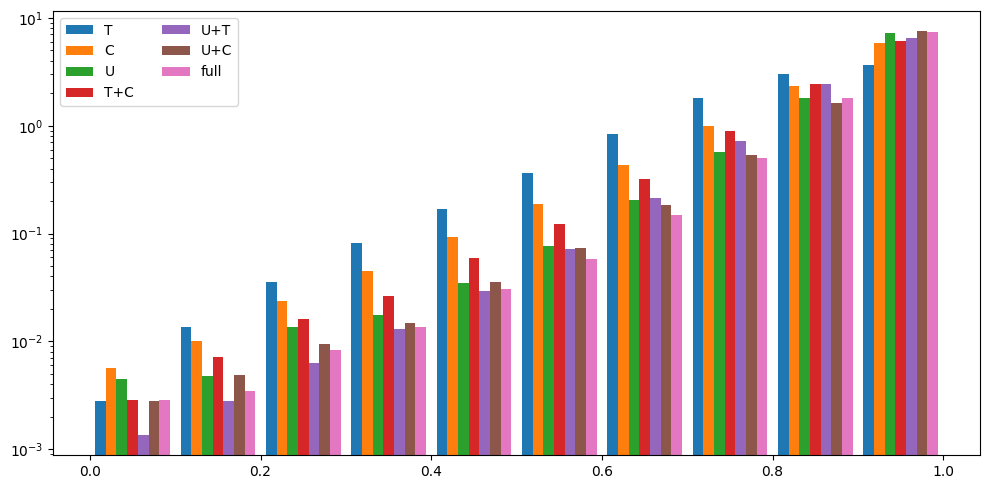

Neighborhood size: 55


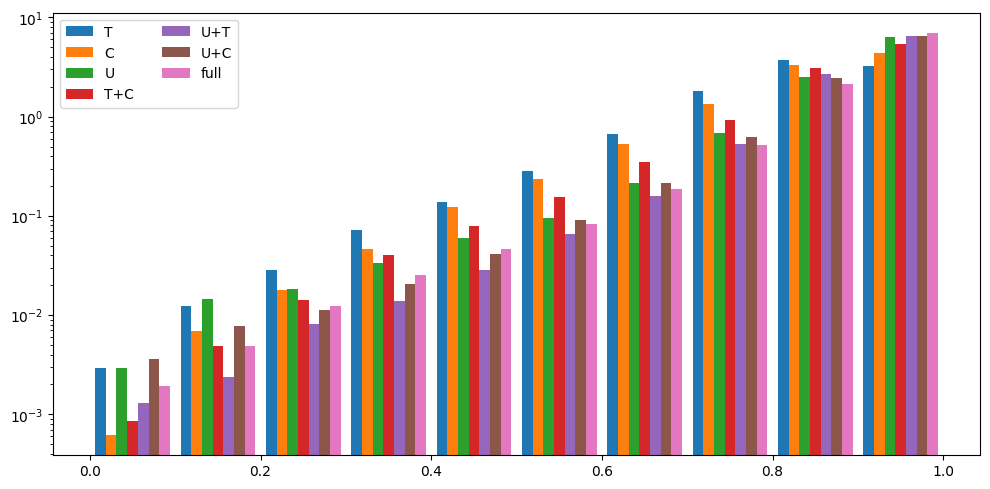

Neighborhood size: 105


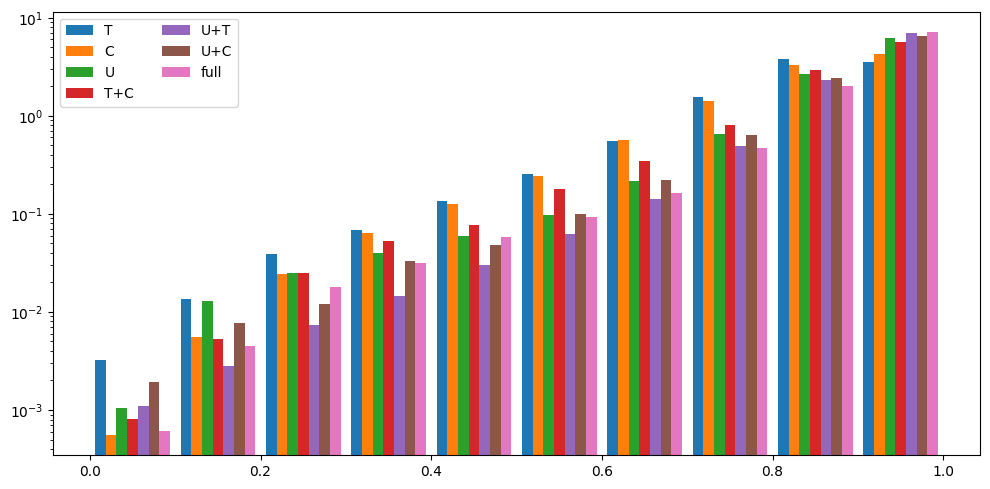

Neighborhood size: 155


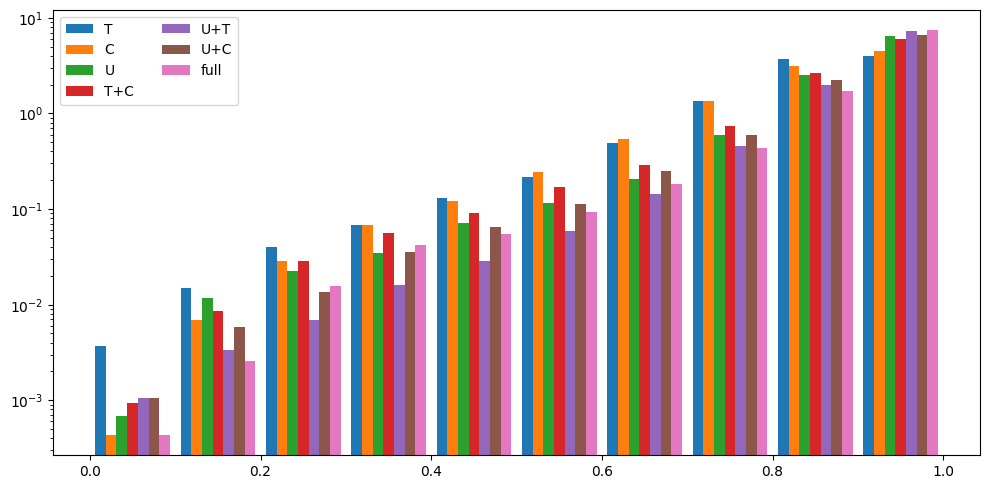

Neighborhood size: 205


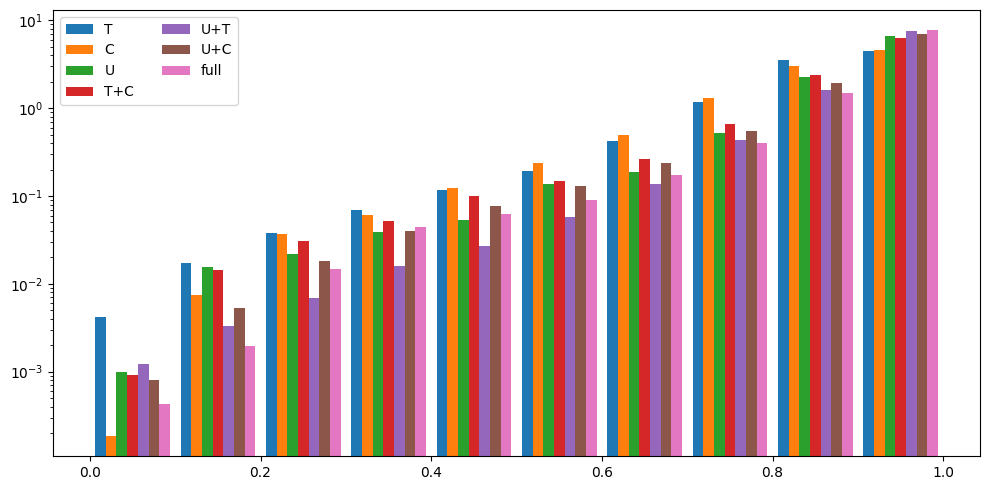

Neighborhood size: 255


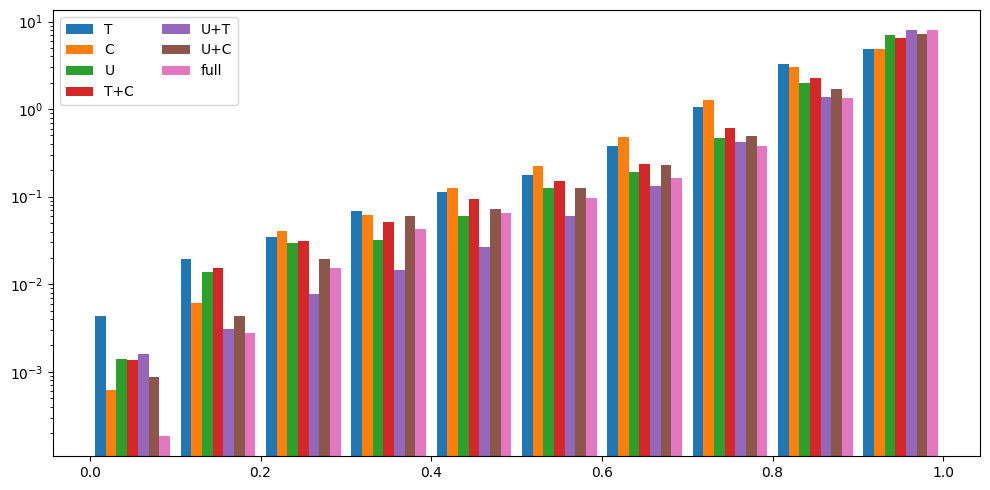

Neighborhood size: 305


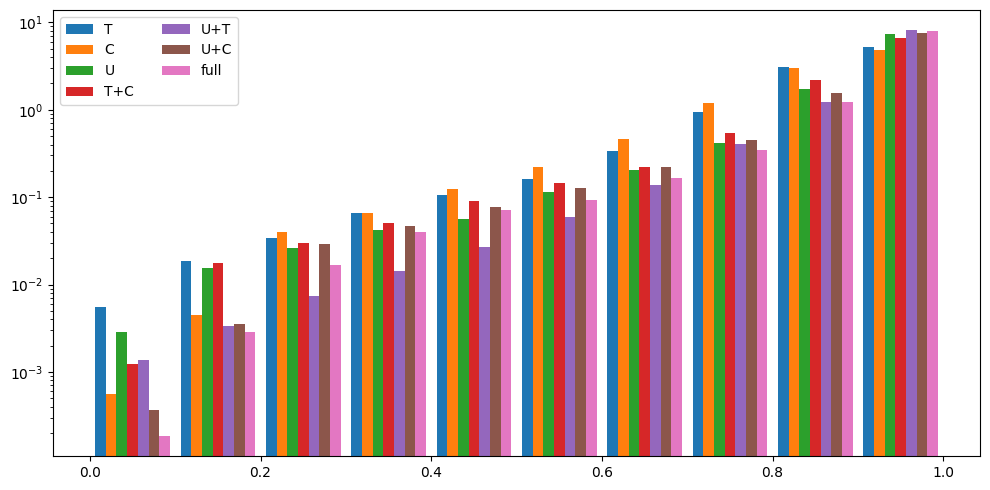

Neighborhood size: 355


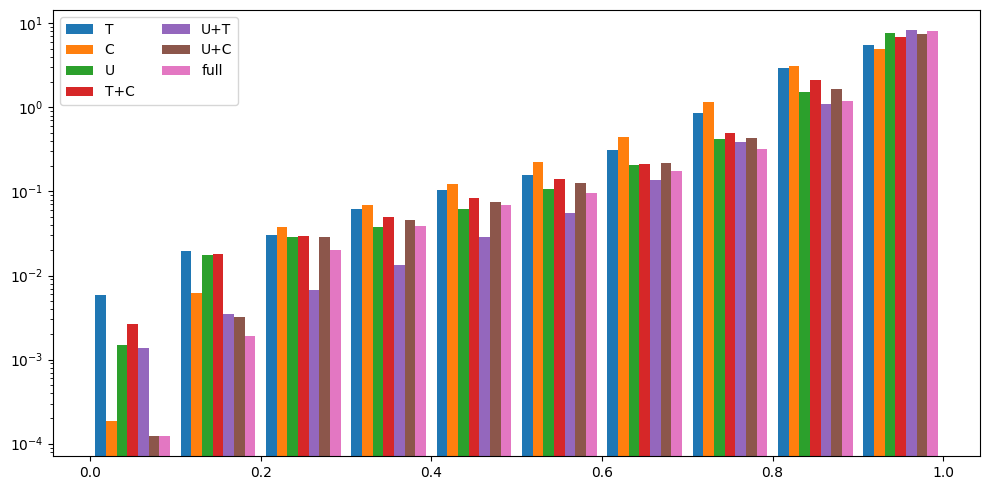

In [23]:
### Histogram of the results with different neighborhood sizes
for nbd_num in range (5,400,50):
    print("Neighborhood size:",nbd_num)
    trust_tda=pairwise_local_trustworthiness_flatten_parallel(embedding_tda_list,k=nbd_num)
    trust_conch=pairwise_local_trustworthiness_flatten_parallel(embedding_conch_list,k=nbd_num)
    trust_uni=pairwise_local_trustworthiness_flatten_parallel(embedding_uni_list,k=nbd_num)
    trust_tdaconch=pairwise_local_trustworthiness_flatten_parallel(embedding_tdaconch_list,k=nbd_num)
    trust_unitda=pairwise_local_trustworthiness_flatten_parallel(embedding_unitda_list,k=nbd_num)
    trust_uniconch=pairwise_local_trustworthiness_flatten_parallel(embedding_uniconch_list,k=nbd_num)
    trust_uniconchtda=pairwise_local_trustworthiness_flatten_parallel(embedding_uniconchtda_list,k=nbd_num)

    label_list=['T','C','U','T+C','U+T','U+C','full']
    data_list=[trust_tda,trust_conch,trust_uni,trust_tdaconch,trust_unitda, trust_uniconch,trust_uniconchtda]
    n_series=7
    bins = np.linspace(0.0, 1.0, 11)
    bin_centers = (bins[:-1] + bins[1:]) / 2
    bin_width = bins[1] - bins[0]

    ### Visualizations
    bar_width = bin_width / (n_series + 1)
    offsets = (
        np.arange(n_series) - (n_series - 1) / 2
    ) * bar_width

    plt.figure(figsize=(10, 5))

    for i, data in enumerate(data_list):
        hist, _ = np.histogram(data, bins=bins,density=True)
        plt.bar(
            bin_centers + offsets[i],
            hist,
            width=bar_width,
            label=label_list[i]
        )

    plt.yscale('log')
    plt.legend(ncol=2)
    plt.tight_layout()
    plt.show()

### Focusing on stable points by taking minimum pointwise trustworthiness for each point.

In [25]:
params = [
    (i, j, k)
    for i, j, k in product(range(11), range(11), range(5, 400, 20))
]
def compute_trust_tda(i, j, k):
    return local_trustworthiness(
        embedding_tda_list[i],
        embedding_tda_list[j],
        k=k
    )
def compute_trust_conch(i, j, k):
    return local_trustworthiness(
        embedding_conch_list[i],
        embedding_conch_list[j],
        k=k
    )
def compute_trust_uni(i, j, k):
    return local_trustworthiness(
        embedding_uni_list[i],
        embedding_uni_list[j],
        k=k
    )
def compute_trust_tdaconch(i, j, k):
    return local_trustworthiness(
        embedding_tdaconch_list[i],
        embedding_tdaconch_list[j],
        k=k
    )
def compute_trust_unitda(i, j, k):
    return local_trustworthiness(
        embedding_unitda_list[i],
        embedding_unitda_list[j],
        k=k
    )
def compute_trust_uniconch(i, j, k):
    return local_trustworthiness(
        embedding_uniconch_list[i],
        embedding_uniconch_list[j],
        k=k
    )
def compute_trust_uniconchtda(i, j, k):
    return local_trustworthiness(
        embedding_uniconchtda_list[i],
        embedding_uniconchtda_list[j],
        k=k
    )

trust_list_tda = Parallel(n_jobs=-1)(
    delayed(compute_trust_tda)(i, j, k)
    for i, j, k in tqdm.tqdm(params)
)
trust_list_conch = Parallel(n_jobs=-1)(
    delayed(compute_trust_conch)(i, j, k)
    for i, j, k in tqdm.tqdm(params)
)
trust_list_uni = Parallel(n_jobs=-1)(
    delayed(compute_trust_uni)(i, j, k)
    for i, j, k in tqdm.tqdm(params)
)
trust_list_tdaconch = Parallel(n_jobs=-1)(
    delayed(compute_trust_tdaconch)(i, j, k)
    for i, j, k in tqdm.tqdm(params)
)
trust_list_unitda = Parallel(n_jobs=-1)(
    delayed(compute_trust_unitda)(i, j, k)
    for i, j, k in tqdm.tqdm(params)
)
trust_list_uniconch = Parallel(n_jobs=-1)(
    delayed(compute_trust_uniconch)(i, j, k)
    for i, j, k in tqdm.tqdm(params)
)
trust_list_uniconchtda = Parallel(n_jobs=-1)(
    delayed(compute_trust_uniconchtda)(i, j, k)
    for i, j, k in tqdm.tqdm(params)
)
trust_list_tda=np.array(trust_list_tda)
trust_list_conch=np.array(trust_list_conch)
trust_list_uni=np.array(trust_list_uni)
trust_list_tdaconch=np.array(trust_list_tdaconch)
trust_list_unitda=np.array(trust_list_unitda)
trust_list_uniconch=np.array(trust_list_uniconch)
trust_list_uniconchtda=np.array(trust_list_uniconchtda)
### Taking minimum
trust_list_tda_min=np.min(trust_list_tda,axis=0)
trust_list_conch_min=np.min(trust_list_conch,axis=0)
trust_list_uni_min=np.min(trust_list_uni,axis=0)
trust_list_tdaconch_min=np.min(trust_list_tdaconch,axis=0)
trust_list_unitda_min=np.min(trust_list_unitda,axis=0)
trust_list_uniconch_min=np.min(trust_list_uniconch,axis=0)
trust_list_uniconchtda_min=np.min(trust_list_uniconchtda,axis=0)


100%|██████████| 2420/2420 [00:29<00:00, 82.27it/s]


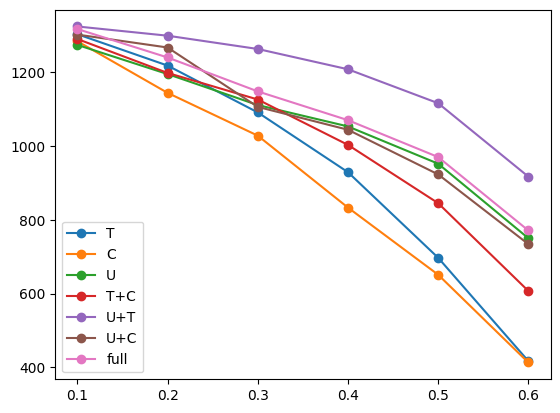

In [26]:
### Stable points selection with full validation dataset
stable_tda=[]
stable_conch=[]
stable_uni=[]
stable_tdaconch=[]
stable_unitda=[]
stable_uniconch=[]
stable_uniconchtda=[]

for trust_thres in [0.1,0.2,0.3,0.4,0.5,0.6]:
    trust_spots_tda=np.where(trust_list_tda_min>trust_thres)[0]
    trust_spots_conch=np.where(trust_list_conch_min>trust_thres)[0]
    trust_spots_uni=np.where(trust_list_uni_min>trust_thres)[0]
    trust_spots_tdaconch=np.where(trust_list_tdaconch_min>trust_thres)[0]
    trust_spots_unitda=np.where(trust_list_unitda_min>trust_thres)[0]
    trust_spots_uniconch=np.where(trust_list_uniconch_min>trust_thres)[0]
    trust_spots_uniconchtda=np.where(trust_list_uniconchtda_min>trust_thres)[0]
    ### Record the number of stable points with each threshold value
    stable_tda.append(len(trust_spots_tda))
    stable_conch.append(len(trust_spots_conch))
    stable_uni.append(len(trust_spots_uni))
    stable_tdaconch.append(len(trust_spots_tdaconch))
    stable_unitda.append(len(trust_spots_unitda))
    stable_uniconch.append(len(trust_spots_uniconch))
    stable_uniconchtda.append(len(trust_spots_uniconchtda))

### Visualization
x=[0.1,0.2,0.3,0.4,0.5,0.6]
plt.plot(x,stable_tda,marker='o',label='T')
plt.plot(x,stable_conch,marker='o',label='C')
plt.plot(x,stable_uni,marker='o',label='U')
plt.plot(x,stable_tdaconch,marker='o',label='T+C')
plt.plot(x,stable_unitda,marker='o',label='U+T')
plt.plot(x,stable_uniconch,marker='o',label='U+C')
plt.plot(x,stable_uniconchtda,marker='o',label='full')
plt.legend()
plt.show()

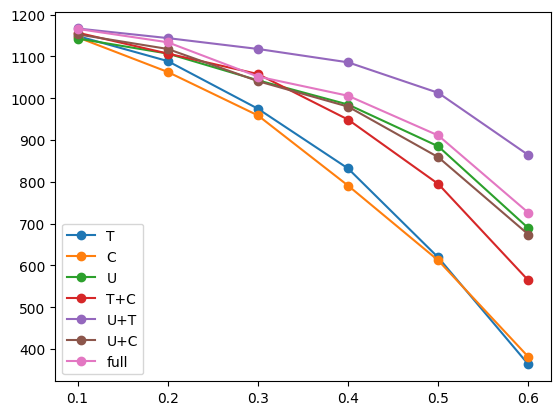

In [27]:
### Stable points selection with tub&por part in validation dataset
stable_tda=[]
stable_conch=[]
stable_uni=[]
stable_tdaconch=[]
stable_unitda=[]
stable_uniconch=[]
stable_uniconchtda=[]

for trust_thres in [0.1,0.2,0.3,0.4,0.5,0.6]:
    trust_spots_tda=np.where(trust_list_tda_min>trust_thres)[0]
    trust_spots_conch=np.where(trust_list_conch_min>trust_thres)[0]
    trust_spots_uni=np.where(trust_list_uni_min>trust_thres)[0]
    trust_spots_tdaconch=np.where(trust_list_tdaconch_min>trust_thres)[0]
    trust_spots_unitda=np.where(trust_list_unitda_min>trust_thres)[0]
    trust_spots_uniconch=np.where(trust_list_uniconch_min>trust_thres)[0]
    trust_spots_uniconchtda=np.where(trust_list_uniconchtda_min>trust_thres)[0]

    ### Focus on tub&por parts
    tubpor_tda_indices = [i for i, v in enumerate(y_val[trust_spots_tda]) if v in (2, 3, 5, 6)]### 2,3,5,6 are the indices for por1, por2, tub1, tub2
    tubpor_conch_indices = [i for i, v in enumerate(y_val[trust_spots_conch]) if v in (2, 3, 5, 6)]
    tubpor_uni_indices = [i for i, v in enumerate(y_val[trust_spots_uni]) if v in (2, 3, 5, 6)]
    tubpor_tdaconch_indices = [i for i, v in enumerate(y_val[trust_spots_tdaconch]) if v in (2, 3, 5, 6)]
    tubpor_unitda_indices = [i for i, v in enumerate(y_val[trust_spots_unitda]) if v in (2, 3, 5, 6)]
    tubpor_uniconch_indices = [i for i, v in enumerate(y_val[trust_spots_uniconch]) if v in (2, 3, 5, 6)]
    tubpor_uniconchtda_indices = [i for i, v in enumerate(y_val[trust_spots_uniconchtda]) if v in (2, 3, 5, 6)]
    ### Record the number of stable points with each threshold value
    stable_tda.append(len(tubpor_tda_indices))
    stable_conch.append(len(tubpor_conch_indices))
    stable_uni.append(len(tubpor_uni_indices))
    stable_tdaconch.append(len(tubpor_tdaconch_indices))
    stable_unitda.append(len(tubpor_unitda_indices))
    stable_uniconch.append(len(tubpor_uniconch_indices))
    stable_uniconchtda.append(len(tubpor_uniconchtda_indices))
### Visualization
x=[0.1,0.2,0.3,0.4,0.5,0.6]
plt.plot(x,stable_tda,marker='o',label='T')
plt.plot(x,stable_conch,marker='o',label='C')
plt.plot(x,stable_uni,marker='o',label='U')
plt.plot(x,stable_tdaconch,marker='o',label='T+C')
plt.plot(x,stable_unitda,marker='o',label='U+T')
plt.plot(x,stable_uniconch,marker='o',label='U+C')
plt.plot(x,stable_uniconchtda,marker='o',label='full')

plt.legend()
plt.show()

### Visualization of stable points with U+T and threshold value 0.4 (black points are unstable)

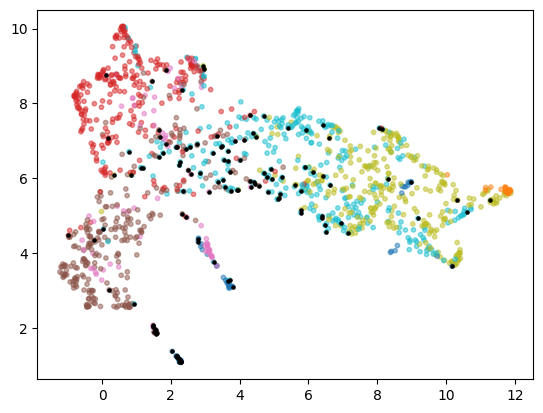

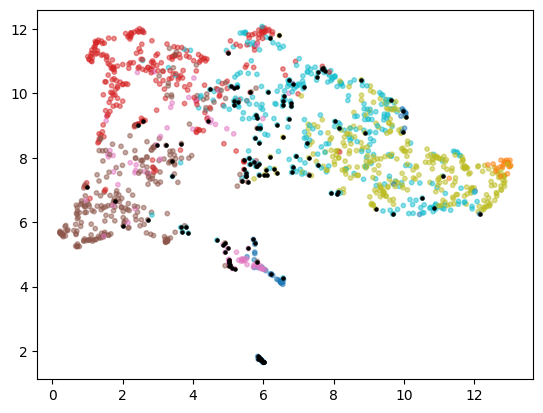

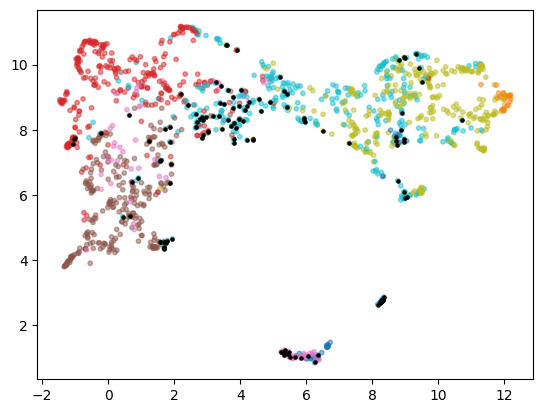

In [28]:
trust_thres=0.4
trust_spots_unitda=np.where(trust_list_unitda_min>trust_thres)[0]
distrust_spots_unitda=np.where(trust_list_unitda_min<=trust_thres)[0]
trust_spots_uniconchtda=np.where(trust_list_uniconchtda_min>trust_thres)[0]
distrust_spots_uniconchtda=np.where(trust_list_uniconchtda_min<=trust_thres)[0]
trust_spots_uni=np.where(trust_list_uni_min>trust_thres)[0]
distrust_spots_uni=np.where(trust_list_uni_min<=trust_thres)[0]

plt.scatter(embedding_unitda_list[0][:,0],embedding_unitda_list[0][:,1],c=(y_val),cmap='tab10',s=10,alpha=0.5)
plt.scatter(embedding_unitda_list[0][distrust_spots_unitda,0],embedding_unitda_list[0][distrust_spots_unitda,1],c="k",s=5)
plt.show()
plt.scatter(embedding_unitda_list[5][:,0],embedding_unitda_list[5][:,1],c=(y_val),cmap='tab10',s=10,alpha=0.5)
plt.scatter(embedding_unitda_list[5][distrust_spots_unitda,0],embedding_unitda_list[5][distrust_spots_unitda,1],c="k",s=5)
plt.show()
plt.scatter(embedding_unitda_list[10][:,0],embedding_unitda_list[10][:,1],c=(y_val),cmap='tab10',s=10,alpha=0.5)
plt.scatter(embedding_unitda_list[10][distrust_spots_unitda,0],embedding_unitda_list[10][distrust_spots_unitda,1],c="k",s=5)

plt.show()

### Pointwise trustworthiness after point selection

Neighborhood size: 5


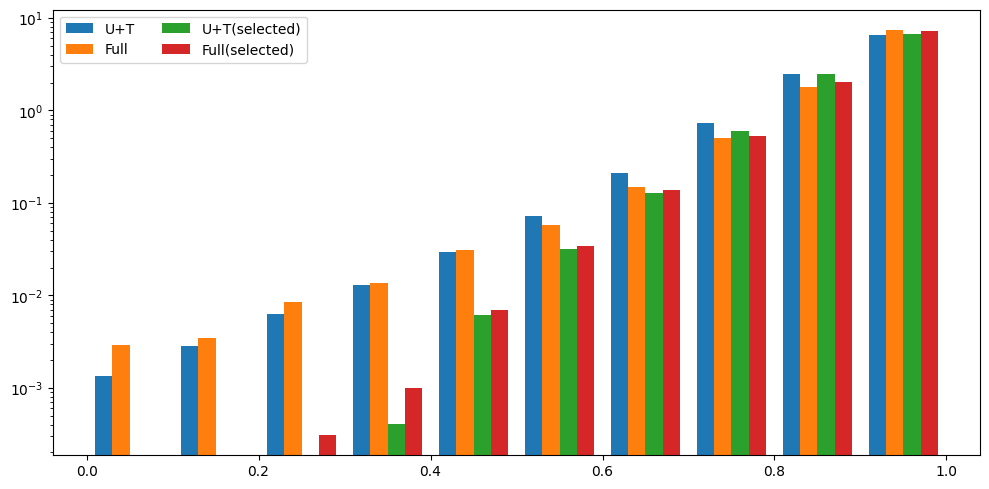

Neighborhood size: 55


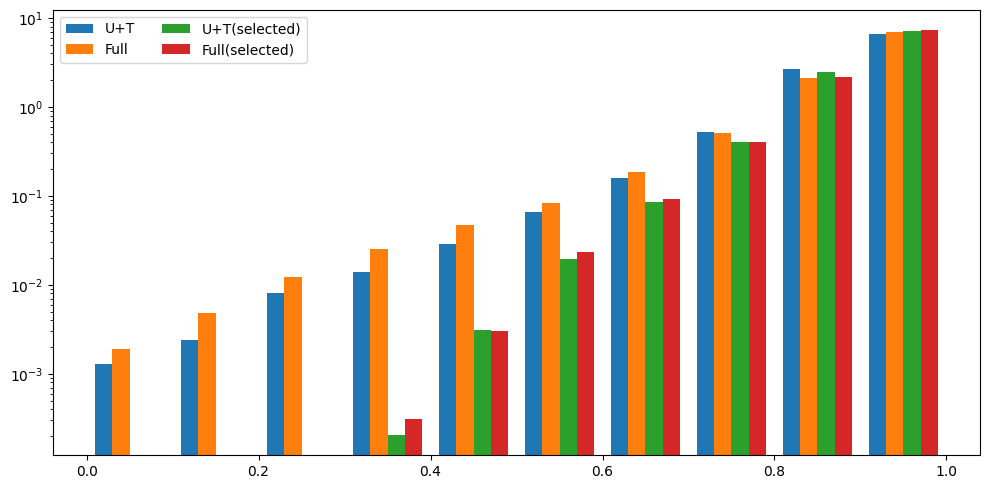

Neighborhood size: 105


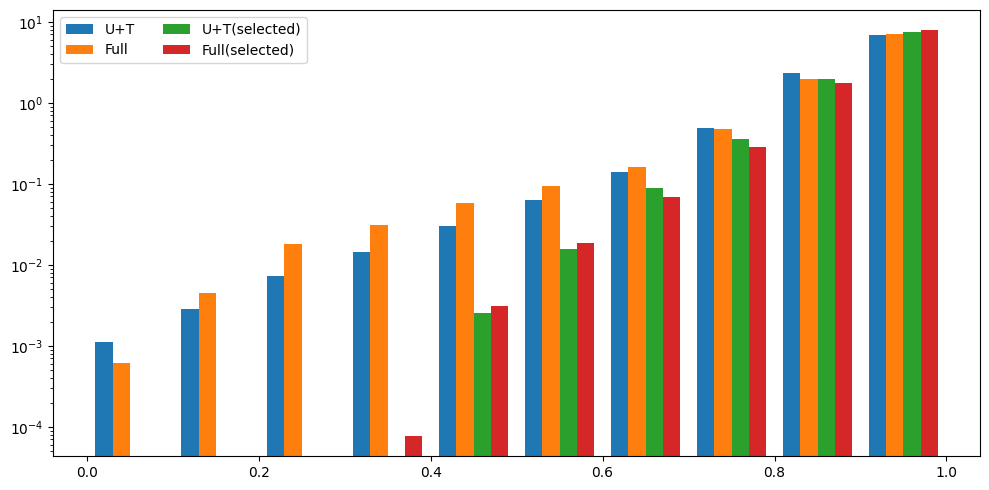

Neighborhood size: 155


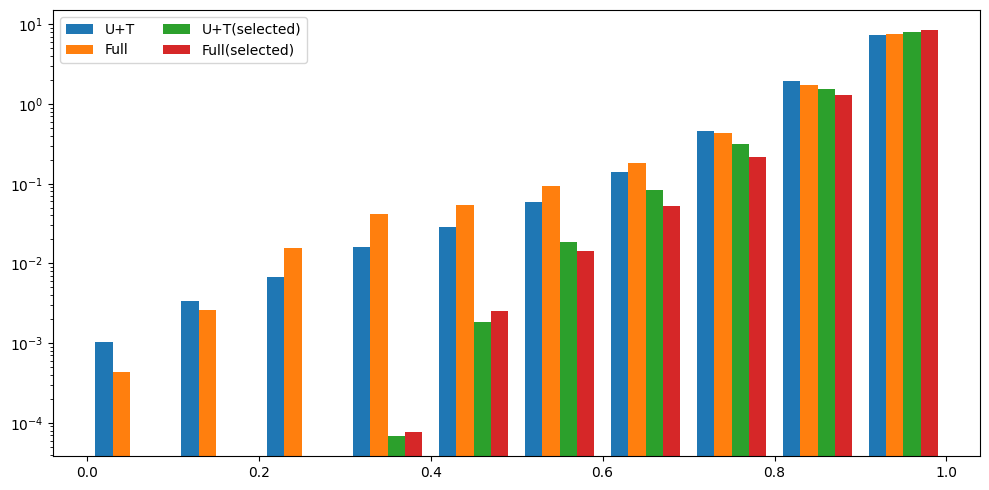

Neighborhood size: 205


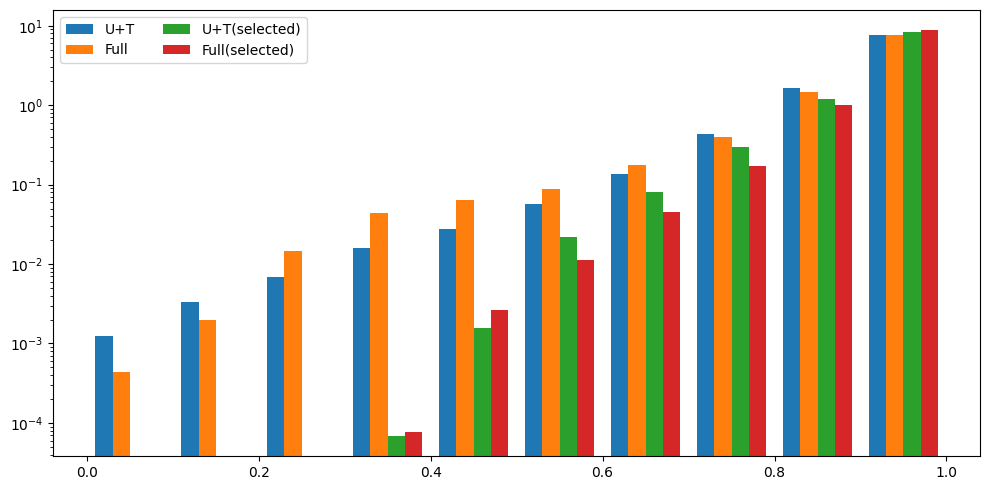

Neighborhood size: 255


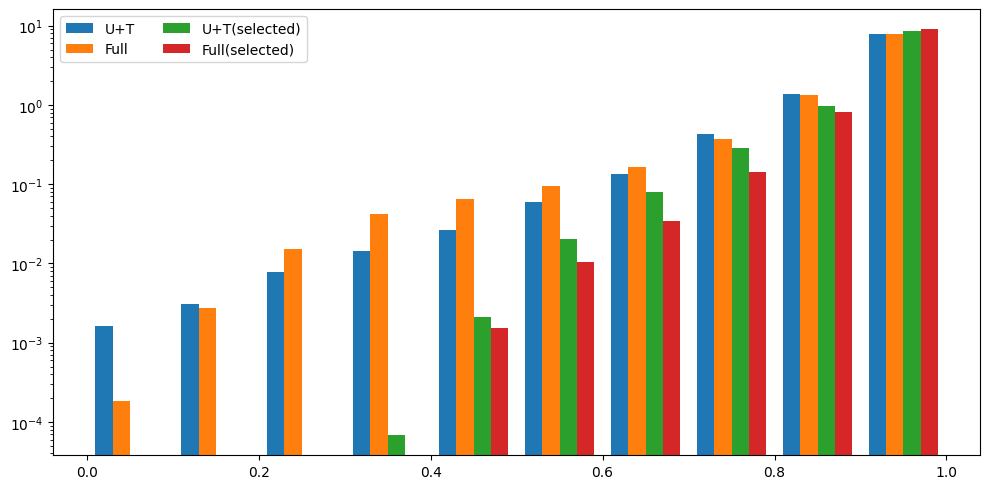

Neighborhood size: 305


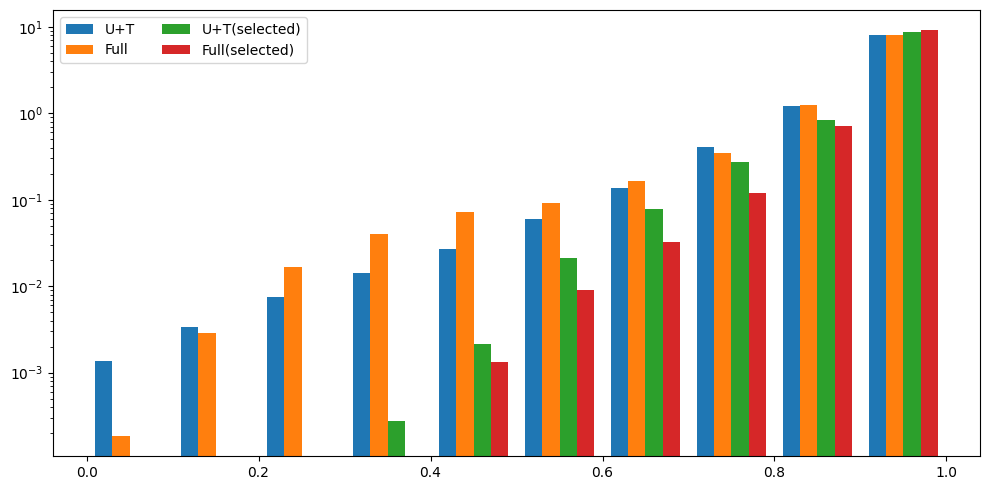

Neighborhood size: 355


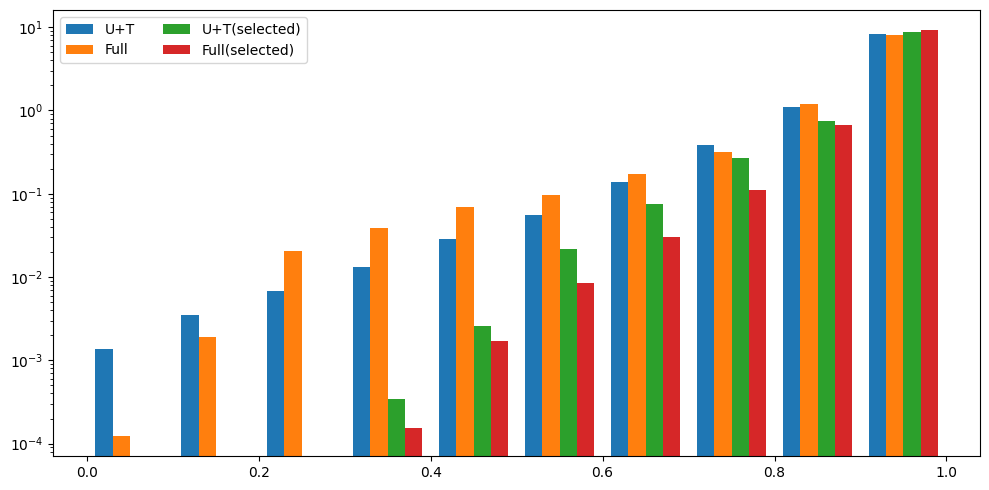

In [ ]:
### Point selection with U+T and full
trust_thres=0.4
trust_spots_unitda=np.where(trust_list_unitda_min>trust_thres)[0]
distrust_spots_unitda=np.where(trust_list_unitda_min<=trust_thres)[0]
trust_spots_uniconchtda=np.where(trust_list_uniconchtda_min>trust_thres)[0]
distrust_spots_uniconchtda=np.where(trust_list_uniconchtda_min<=trust_thres)[0]
trust_spots_uni=np.where(trust_list_uni_min>trust_thres)[0]
distrust_spots_uni=np.where(trust_list_uni_min<=trust_thres)[0]

### Selecting points in the embedding
embedding_unitda_list_selected=embedding_unitda_list[:,trust_spots_unitda,:]
embedding_uniconchtda_list_selected=embedding_uniconchtda_list[:,trust_spots_uniconchtda,:]

### Histogram of the results
for nbd_num in range (5,400,50):
    print("Neighborhood size:",nbd_num)
    trust_unitda=pairwise_local_trustworthiness_flatten_parallel(embedding_unitda_list,k=nbd_num)
    trust_uniconchtda=pairwise_local_trustworthiness_flatten_parallel(embedding_uniconchtda_list,k=nbd_num)
    trust_unitda_selected=pairwise_local_trustworthiness_flatten_parallel(embedding_unitda_list_selected,k=nbd_num)
    trust_uniconchtda_selected=pairwise_local_trustworthiness_flatten_parallel(embedding_uniconchtda_list_selected,k=nbd_num)

    label_list=['U+T','Full', 'U+T(selected)','Full(selected)']
    data_list=[trust_unitda, trust_uniconchtda,trust_unitda_selected,trust_uniconchtda_selected]
    n_series=4
    bins = np.linspace(0.0, 1.0, 11)
    bin_centers = (bins[:-1] + bins[1:]) / 2
    bin_width = bins[1] - bins[0]

    ### Visualization
    bar_width = bin_width / (n_series + 1)
    offsets = (
        np.arange(n_series) - (n_series - 1) / 2
    ) * bar_width

    plt.figure(figsize=(10, 5))

    for i, data in enumerate(data_list):
        hist, _ = np.histogram(data, bins=bins,density=True)
        plt.bar(
            bin_centers + offsets[i],
            hist,
            width=bar_width,
            label=label_list[i]
        )
    plt.yscale('log')
    plt.legend(ncol=2)
    plt.tight_layout()
    plt.show()

### We can see that point selection resulted in higher pointwise trustworthiness

### To summarize,
- We extracted gastric cancer pathology patch image features with topological data analysis and foundation models.
- We evaluated these features and combinations by measuring the output distribution stability against train subset configurations.
- U+T and full resulted in high stability, enabling fewer loss of data when focusing on stable parts of the distributions.